In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

2026-01-30 10:54:29.860149: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769770470.151035      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769770470.238048      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769770470.972690      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769770470.972740      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769770470.972744      55 computation_placer.cc:177] computation placer alr

In [9]:
import os

os.listdir("/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train")

['Tomato___Late_blight',
 'Tomato___healthy',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Potato___healthy',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Tomato___Early_blight',
 'Tomato___Septoria_leaf_spot',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Strawberry___Leaf_scorch',
 'Peach___healthy',
 'Apple___Apple_scab',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Bacterial_spot',
 'Apple___Black_rot',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Peach___Bacterial_spot',
 'Apple___Cedar_apple_rust',
 'Tomato___Target_Spot',
 'Pepper,_bell___healthy',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Potato___Late_blight',
 'Tomato___Tomato_mosaic_virus',
 'Strawberry___healthy',
 'Apple___healthy',
 'Grape___Black_rot',
 'Potato___Early_blight',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Common_rust_',
 'Grape___Esca_(Black_Measles)',
 'Raspberry___healthy'

In [2]:
#Data pre-processing - Training
training_set = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    verbose=True,
)


Found 70295 files belonging to 38 classes.


I0000 00:00:1769770518.498045      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [3]:
#Data pre-processing - Validation
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [7]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [8]:
for x, y in training_set:
    print(x, x.shape)
    print(y, y.shape)
    break

tf.Tensor(
[[[[128.25 127.25 123.25]
   [121.75 120.75 116.75]
   [114.5  113.5  109.5 ]
   ...
   [116.25 120.25 121.25]
   [122.25 126.25 127.25]
   [122.25 126.25 127.25]]

  [[118.75 117.75 113.75]
   [120.5  119.5  115.5 ]
   [127.   126.   122.  ]
   ...
   [118.25 122.25 123.25]
   [120.75 124.75 125.75]
   [121.25 125.25 126.25]]

  [[119.25 118.25 114.25]
   [121.25 120.25 116.25]
   [118.5  117.5  113.5 ]
   ...
   [120.75 124.75 125.75]
   [120.   124.   125.  ]
   [122.25 126.25 127.25]]

  ...

  [[ 96.75 101.75  95.75]
   [ 98.5  103.5   97.5 ]
   [ 94.25  99.25  93.25]
   ...
   [101.25 110.25 107.25]
   [100.25 109.25 106.25]
   [ 97.5  106.5  103.5 ]]

  [[ 97.   102.    96.  ]
   [ 99.5  104.5   98.5 ]
   [ 94.25  99.25  93.25]
   ...
   [105.25 114.25 111.25]
   [103.25 112.25 109.25]
   [ 99.75 108.75 105.75]]

  [[ 98.75 103.75  97.75]
   [100.75 105.75  99.75]
   [104.5  109.5  103.5 ]
   ...
   [102.5  111.5  108.5 ]
   [101.75 110.75 107.75]
   [102.75 111.75 10

In [4]:
#model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [5]:
model = Sequential()

In [6]:
#conv layers
model.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu', input_shape = [128, 128, 3]))
model.add(Conv2D(filters = 32, kernel_size = 3, activation = 'relu'))
model.add(MaxPool2D(pool_size = 2, strides = 2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.add(Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 64, kernel_size = 3, activation = 'relu'))
model.add(MaxPool2D(pool_size = 2, strides = 2))

In [8]:
model.add(Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 128, kernel_size = 3, activation = 'relu'))
model.add(MaxPool2D(pool_size = 2, strides = 2))

In [9]:
model.add(Conv2D(filters = 256, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 256, kernel_size = 3, activation = 'relu'))
model.add(MaxPool2D(pool_size = 2, strides = 2))

In [10]:
model.add(Conv2D(filters = 512, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 512, kernel_size = 3, activation = 'relu'))
model.add(MaxPool2D(pool_size = 2, strides = 2))

In [11]:
model.add(Flatten())

In [12]:
model.add(Dropout(0.25))

In [13]:
model.add(Dense(units = 1500, activation = 'relu'))

In [14]:
model.add(Dropout(0.4))

In [15]:
#output layer
model.add(Dense(units = 38, activation = 'softmax'))

In [16]:
#compile
model.compile(optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0001), loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#model training
training_history = model.fit(x = training_set, validation_data = validation_set, epochs = 10)

Epoch 1/10


I0000 00:00:1769770590.726362     129 service.cc:152] XLA service 0x7c7740016290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769770590.726405     129 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769770591.509229     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


   5/2197 ━━━━━━━━━━━━━━━━━━━━ 1:08 31ms/step - accuracy: 0.0223 - loss: 4.0057 

I0000 00:00:1769770599.137088     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 150s 63ms/step - accuracy: 0.4065 - loss: 2.0885 - val_accuracy: 0.8372 - val_loss: 0.5186
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 73s 33ms/step - accuracy: 0.8410 - loss: 0.5152 - val_accuracy: 0.9109 - val_loss: 0.2703
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 73s 33ms/step - accuracy: 0.9086 - loss: 0.2859 - val_accuracy: 0.9254 - val_loss: 0.2352
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 73s 33ms/step - accuracy: 0.9389 - loss: 0.1920 - val_accuracy: 0.9472 - val_loss: 0.1589
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 72s 33ms/step - accuracy: 0.9547 - loss: 0.1389 - val_accuracy: 0.9561 - val_loss: 0.1390
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 73s 33ms/step - accuracy: 0.9656 - loss: 0.1032 - val_accuracy: 0.9636 - val_loss: 0.1160
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 72s 33ms/step - accuracy: 0.9694 - loss: 0.0907 - val_accuracy: 0.9628 - val_loss: 0.1324
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 73s 33ms/step - accuracy: 0.9738 - loss: 0.0

In [19]:
#model evaluation on training set
train_loss, train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.9765 - loss: 0.0721


In [20]:
print(train_loss, train_acc)

0.06623382866382599 0.9783483743667603


In [21]:
#model evaluation on validation set
val_loss, val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9548 - loss: 0.1551


In [22]:
print(val_loss, val_acc)

0.1541249006986618 0.9529933929443359


In [23]:
#saving the model
model.save("trained_model.keras")

In [24]:
training_history.history

{'accuracy': [0.6064727306365967,
  0.8637883067131042,
  0.916765034198761,
  0.942997395992279,
  0.9572373628616333,
  0.9675083756446838,
  0.9730279445648193,
  0.9761291742324829,
  0.9813358187675476,
  0.9824738502502441],
 'loss': [1.3324189186096191,
  0.43679216504096985,
  0.25752097368240356,
  0.17671217024326324,
  0.13043417036533356,
  0.09841607511043549,
  0.08212234824895859,
  0.07501821964979172,
  0.05964737385511398,
  0.05454084649682045],
 'val_accuracy': [0.8372410535812378,
  0.9108809232711792,
  0.925449550151825,
  0.9472455978393555,
  0.9561233520507812,
  0.9636353254318237,
  0.9628385901451111,
  0.9551559090614319,
  0.9650580286979675,
  0.9529933929443359],
 'val_loss': [0.518592894077301,
  0.2703016400337219,
  0.23519961535930634,
  0.15893934667110443,
  0.13901804387569427,
  0.11596865952014923,
  0.13236503303050995,
  0.15762583911418915,
  0.11266683787107468,
  0.15412494540214539]}

In [25]:
#recording history in json
import json
with open("training_hist.json", "w") as f:
    json.dump(training_history.history, f)

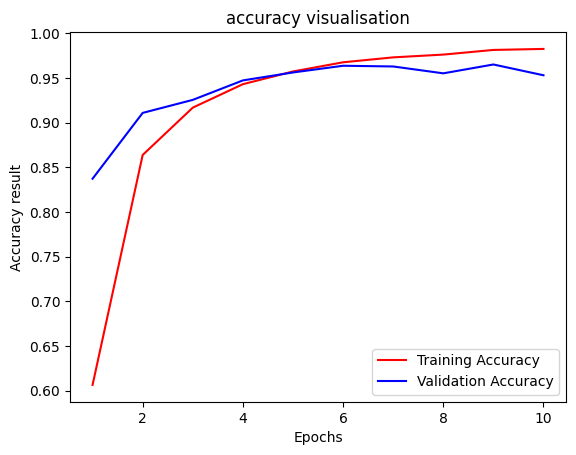

In [26]:
#accuracy visualisation
epochs = range(1, 11)
plt.plot(epochs, training_history.history['accuracy'], color = 'red', label = 'Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color = 'blue', label = 'Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy result")
plt.title("accuracy visualisation")
plt.legend()
plt.show()

In [27]:
#metrics for evaluation
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [28]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [29]:
y_pred = model.predict(test_set)
y_pred, y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step


(array([[9.9999940e-01, 4.6329204e-11, 4.4264922e-11, ..., 1.9241826e-17,
         6.7314432e-18, 3.3463636e-14],
        [1.0000000e+00, 4.0338280e-12, 2.8256484e-12, ..., 1.5393748e-17,
         4.1481528e-18, 1.3807358e-15],
        [1.0000000e+00, 1.5763913e-13, 3.3634318e-10, ..., 5.1887897e-21,
         4.4839884e-19, 2.4669350e-16],
        ...,
        [6.8550335e-12, 9.9598914e-12, 2.5511754e-10, ..., 1.5821851e-11,
         5.0982458e-11, 9.9999964e-01],
        [1.7563227e-12, 6.5579405e-14, 3.2023443e-11, ..., 3.5853272e-11,
         6.9322820e-12, 9.9999976e-01],
        [3.2238694e-14, 2.5022029e-15, 9.0866793e-16, ..., 1.8574314e-14,
         1.4752789e-12, 1.0000000e+00]], dtype=float32),
 (17572, 38))

In [30]:
predicted_categories = tf.argmax(y_pred, axis = 1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [31]:
true_categories = tf.concat([y for x,y in test_set], axis = 0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [32]:
Y_true = tf.argmax(true_categories, axis = 1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

In [34]:
print(classification_report(Y_true, predicted_categories, target_names = class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.96      0.97       504
                                 Apple___Black_rot       0.99      0.98      0.98       497
                          Apple___Cedar_apple_rust       0.99      0.97      0.98       440
                                   Apple___healthy       0.86      0.99      0.92       502
                               Blueberry___healthy       0.97      0.97      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.98       421
                 Cherry_(including_sour)___healthy       1.00      0.97      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.87      0.96      0.92       410
                       Corn_(maize)___Common_rust_       1.00      0.96      0.98       477
               Corn_(maize)___Northern_Leaf_Blight       0.98      0.87      0.

In [35]:
cm = confusion_matrix(Y_true, predicted_categories)
cm

array([[484,   0,   0, ...,   0,   0,   0],
       [  5, 485,   1, ...,   0,   0,   0],
       [  0,   0, 425, ...,   0,   3,   4],
       ...,
       [  0,   0,   0, ..., 489,   0,   0],
       [  0,   0,   0, ...,   0, 447,   0],
       [  0,   0,   0, ...,   0,   0, 476]])

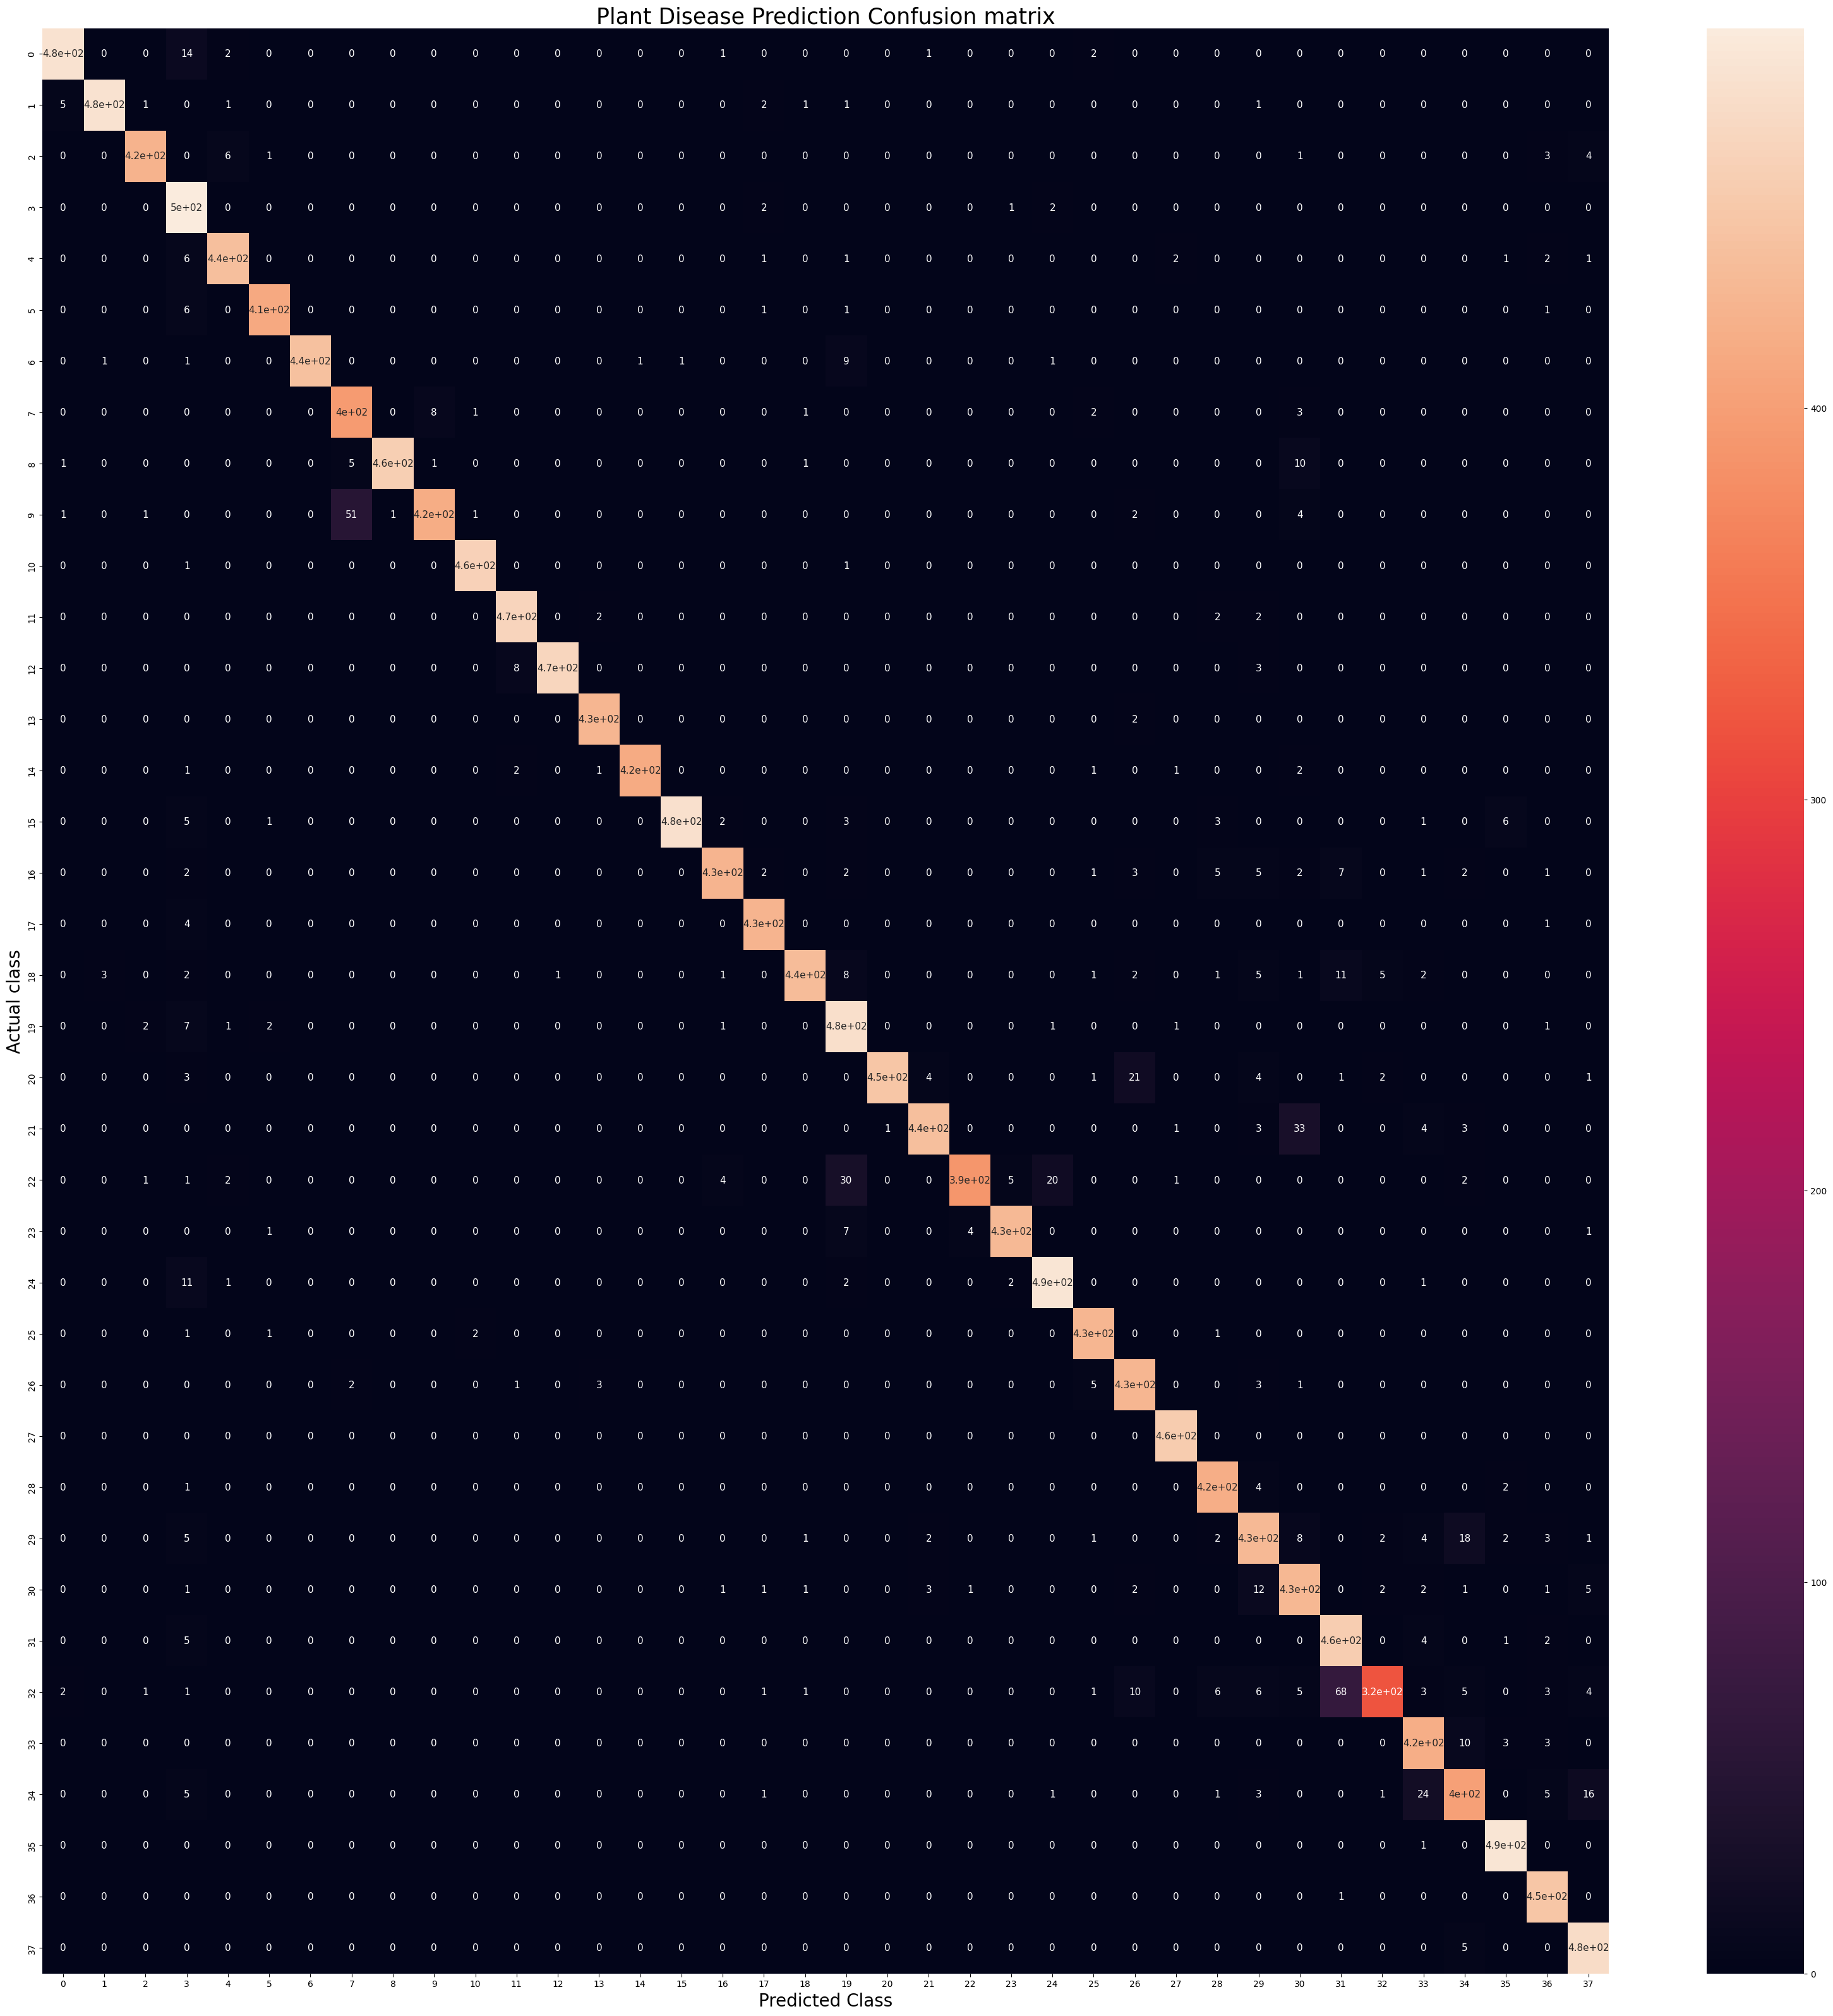

In [36]:
#confusion matrix visualization
plt.figure(figsize = (40, 40))
sns.heatmap(cm, annot = True, annot_kws = {'size': 11})
plt.xlabel("Predicted Class", fontsize = 20)
plt.ylabel("Actual class", fontsize = 20)
plt.title("Plant Disease Prediction Confusion matrix", fontsize = 25)
plt.show()

**Testing the model**

In [37]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

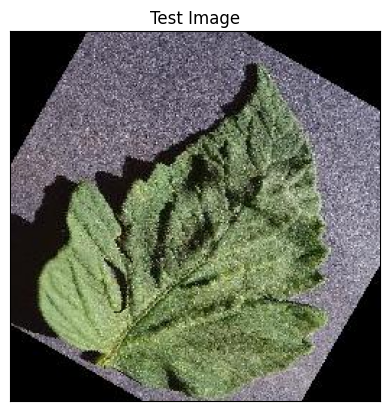

In [38]:
#visualising single image of test set
import cv2
image_path = "/kaggle/input/new-plant-diseases-dataset/test/test/TomatoHealthy3.JPG"

#reading image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #convert bgr img to rgb img

#displaying image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

In [39]:
#testing
image = tf.keras.preprocessing.image.load_img(image_path, target_size = (128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) #convert single img to batch
print(input_arr, input_arr.shape)

[[[[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  ...

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]]] (1, 128, 128, 3)


In [40]:
prediction = model.predict(input_arr)
prediction, prediction.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


(array([[3.8689677e-14, 2.6653686e-16, 9.2351215e-17, 1.2063340e-11,
         3.0755749e-14, 7.4370767e-14, 1.1387379e-16, 3.0948600e-13,
         9.1831342e-16, 1.5890034e-17, 4.1180573e-13, 2.8442974e-20,
         5.4694561e-14, 3.3073455e-19, 2.9669056e-17, 8.5473038e-20,
         3.4340516e-17, 1.8362020e-17, 9.3895308e-19, 6.3593182e-17,
         1.3663299e-11, 3.3886748e-17, 5.7274057e-14, 2.7981469e-15,
         5.3007587e-16, 1.9011939e-09, 9.1413024e-15, 2.0579920e-12,
         3.6502215e-16, 6.1335866e-19, 6.9091044e-12, 8.0354370e-13,
         9.7058050e-15, 8.7583554e-18, 7.0197742e-10, 1.7543100e-17,
         3.2395720e-16, 1.0000000e+00]], dtype=float32),
 (1, 38))

In [41]:
result_index = np.argmax(prediction)
result_index

np.int64(37)

'Tomato___healthy'

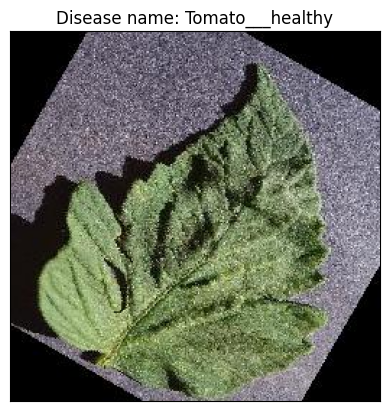

In [42]:
#displaying result of disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease name: {model_prediction}")
plt.xticks([])
plt.yticks([])
model_prediction

In [43]:
import json
with open("class_names.json", "w") as f:
    json.dump(class_name, f)